**Install Required Libaries**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Project/ML/Walmart/Walmart DataSet.csv")  #load dataset
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
columns = df.columns
columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [4]:
df.shape

(6435, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df["Date"] = pd.to_datetime(df["Date"] , format = '%d-%m-%Y')   #Convert Date Column into Datetime datatype

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [8]:
df.head(4)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106


In [9]:
df['Store'].value_counts()

,count
Store,
1,143
2,143
3,143
4,143
5,143
6,143
7,143
8,143
9,143


In [10]:
df.isnull().sum().sum()  #check null values

np.int64(0)

In [11]:
df.duplicated().sum()    #check duplicates

np.int64(0)

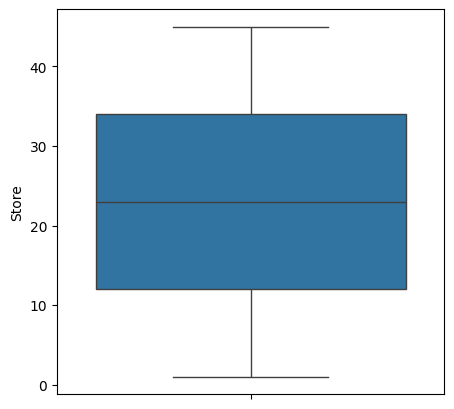

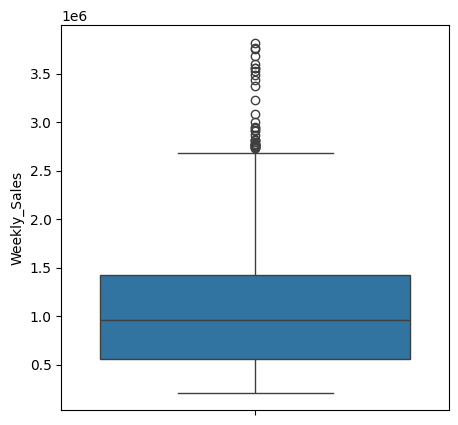

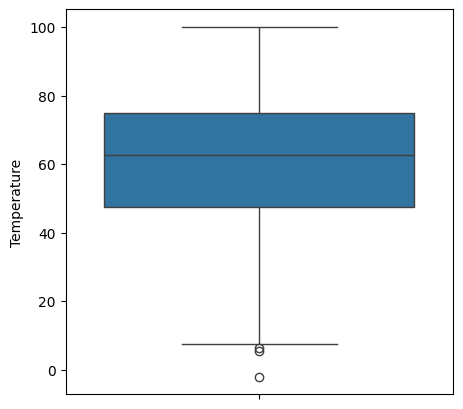

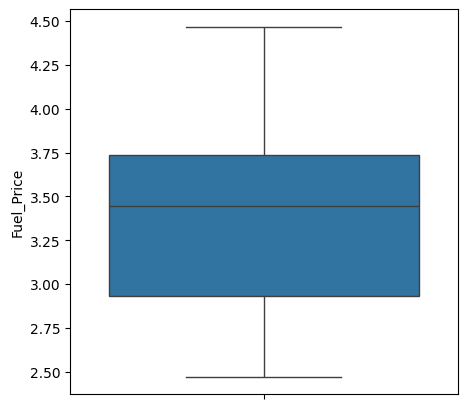

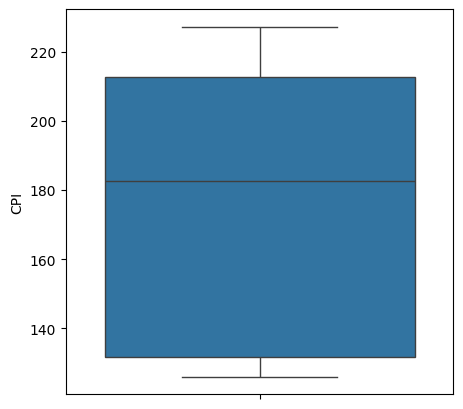

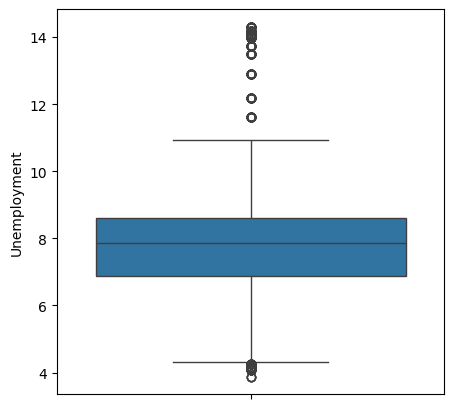

In [12]:
#Outliers

for i in columns:
  if df[i].dtype == 'object' or df[i].dtype == 'datetime64[ns]' or i == 'Holiday_Flag':
    continue
  else:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[i])
    plt.show()

In [13]:
for i in columns:
    if df[i].dtype == 'object' or df[i].dtype == 'datetime64[ns]':
        continue
    else:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[i] >= lower) & (df[i] <= upper)]


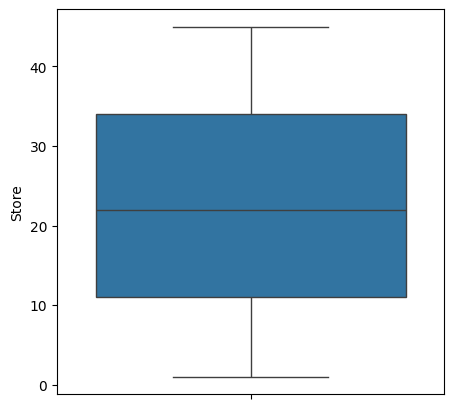

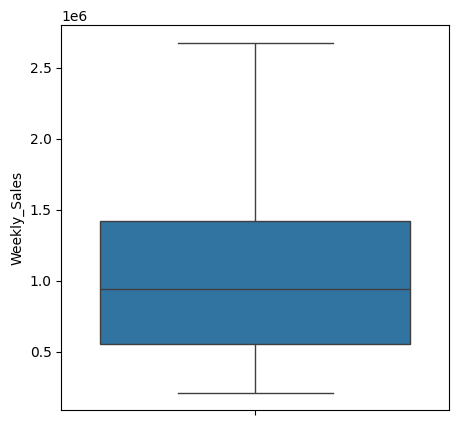

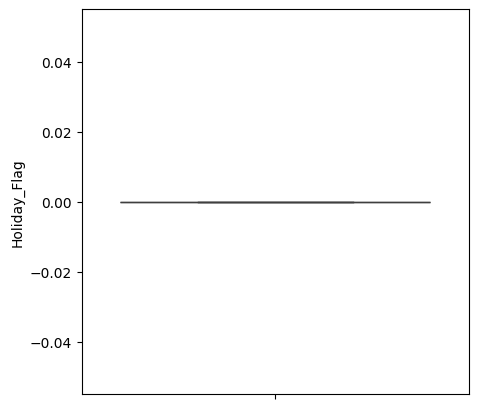

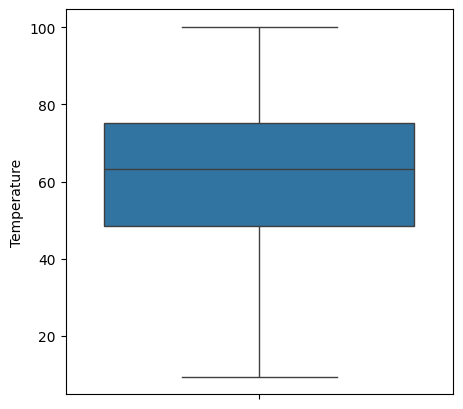

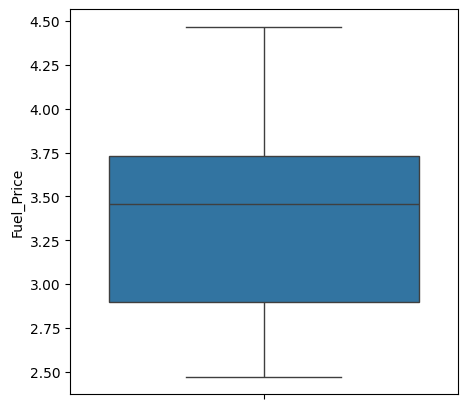

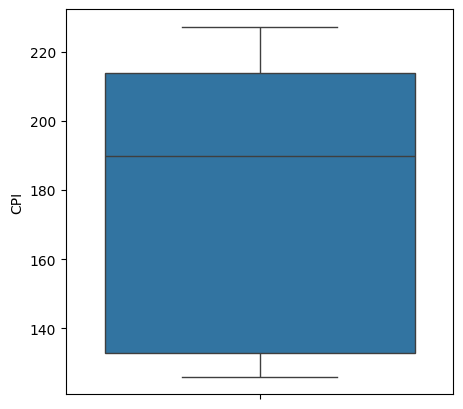

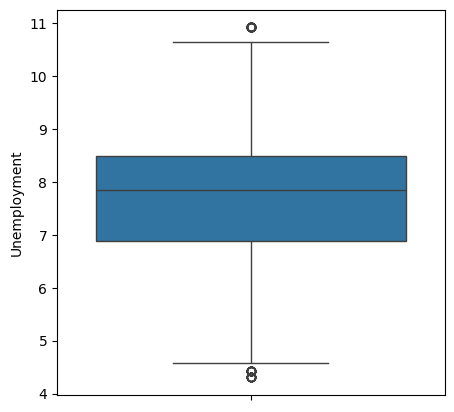

In [14]:
for i in columns:
  if df[i].dtype == 'object' or df[i].dtype == 'datetime64[ns]':
    continue
  else:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[i])
    plt.show()

In [15]:
df.describe(exclude='datetime64[ns]')

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,5507.000000,5.507000e+03,5507.0,5507.000000,5507.000000,5507.000000,5507.000000
mean,22.788814,1.035725e+06,0.0,61.230821,3.350147,175.023995,7.718470
std,13.092433,5.492936e+05,0.0,17.971288,0.460119,39.038267,1.243988
min,1.000000,2.099862e+05,0.0,9.510000,2.472000,126.064000,4.308000
25%,11.000000,5.511051e+05,0.0,48.455000,2.895000,132.761933,6.891000
50%,22.000000,9.439128e+05,0.0,63.350000,3.459000,189.936850,7.852000
75%,34.000000,1.422573e+06,0.0,75.100000,3.732000,213.843625,8.494000
max,45.000000,2.678206e+06,0.0,100.140000,4.468000,227.232807,10.926000


<Axes: >

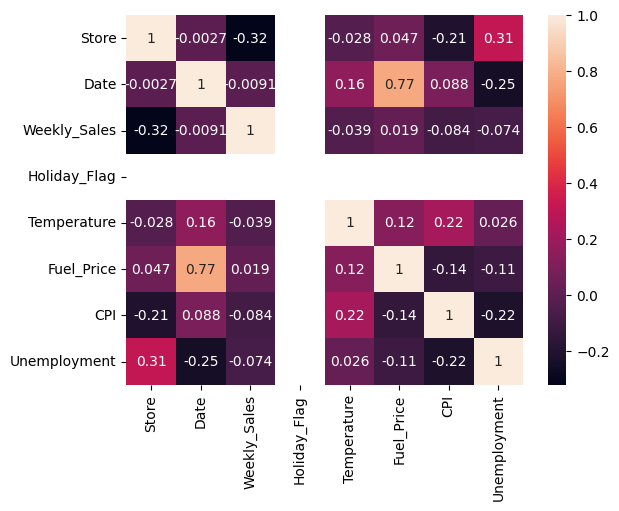

In [16]:
sns.heatmap(df.corr() , annot = True)   # Correlation REpesentation

1a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?

In [17]:
correlation_unemployment = df['Unemployment'].corr(df['Weekly_Sales'])
print(f"Overall correlation between Unemployment and Weekly_Sales: {correlation_unemployment:.4f}\n")

Overall correlation between Unemployment and Weekly_Sales: -0.0737



In [18]:
unemployment_impact = df.groupby('Store')[['Unemployment', 'Weekly_Sales']].corr().unstack().iloc[:,1]
stores_suffering_most = unemployment_impact.sort_values(ascending=True).head(5)

print("Top 5 Stores Most Negatively Affected by Unemployment:")
print(stores_suffering_most)

Top 5 Stores Most Negatively Affected by Unemployment:
Store
44   -0.801376
4    -0.658851
39   -0.427695
13   -0.384296
41   -0.382718
Name: (Unemployment, Weekly_Sales), dtype: float64


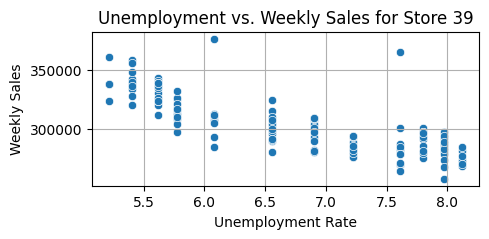

In [19]:
plt.figure(figsize=(5,2))
sns.scatterplot(data=df[df['Store']==44], x='Unemployment', y='Weekly_Sales')
plt.title('Unemployment vs. Weekly Sales for Store 39')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

1b. If the weekly sales show a seasonal trend, when and what could be the reason?

In [20]:
df1 = df.drop(['Holiday_Flag', 'Temperature','Fuel_Price', 'CPI', 'Unemployment'] , axis=1)

In [21]:
df1.groupby(['Date', 'Store'])['Weekly_Sales'].sum().reset_index()

,Date,Store,Weekly_Sales
0,2010-02-05,1,1643690.90
1,2010-02-05,2,2136989.46
2,2010-02-05,3,461622.22
3,2010-02-05,4,2135143.87
4,2010-02-05,5,317173.10
...,...,...,...
5502,2012-10-26,41,1316542.59
5503,2012-10-26,42,514756.08
5504,2012-10-26,43,587603.55
5505,2012-10-26,44,361067.07


In [22]:
df1 = df1.drop('Store' , axis=1)

In [23]:
df1

,Date,Weekly_Sales
0,2010-02-05,1643690.90
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68
5,2010-03-12,1439541.59
...,...,...
6430,2012-09-28,713173.95
6431,2012-10-05,733455.07
6432,2012-10-12,734464.36
6433,2012-10-19,718125.53


In [24]:
df1 = df1.set_index('Date')

In [25]:
df1

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
2010-03-12,1439541.59
...,...
2012-09-28,713173.95
2012-10-05,733455.07
2012-10-12,734464.36


In [26]:
from statsmodels.tsa.stattools import adfuller

In [27]:
result = adfuller(df1)
print(f'p-value={result[1]}')

if(result[1]>0.05):
    print("The series is not stationary")
else:
    print("series is stationary")

p-value=2.3590945269620912e-05
series is stationary


<Axes: xlabel='Date'>

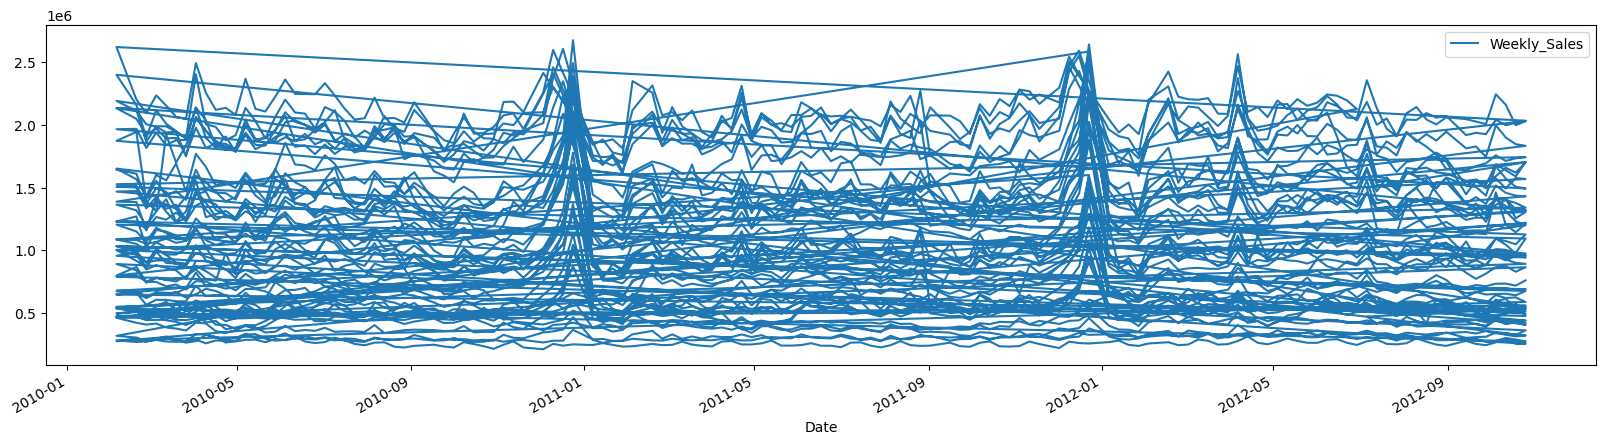

In [28]:
df1.plot(figsize=(20,5))

1c. Does temperature affect the weekly sales in any manner?

In [29]:
correlation = df['Temperature'].corr(df['Weekly_Sales'])
print(f"The correlation between Temperature and Weekly_Sales is: {correlation:.4f}")

The correlation between Temperature and Weekly_Sales is: -0.0394


Yes, Temperature affect the Weekly Sales.
Temperature and Weekly Sales negative weak correlation.

1d. How is the Consumer Price index affecting the weekly sales of various stores?


In [30]:
correlation_CPI = df['CPI'].corr(df['Weekly_Sales'])
print(f"Overall correlation between CPI and Weekly_Sales: {correlation_CPI:.4f}\n")

Overall correlation between CPI and Weekly_Sales: -0.0841



In [31]:
CPI_impact = df.groupby('Store')[['CPI', 'Weekly_Sales']].corr().unstack().iloc[:,1]
stores_suffering_most = CPI_impact.sort_values(ascending=True).head(5)

print("Top 5 Stores Most Negatively Affected by CPI:")
print(stores_suffering_most)

Top 5 Stores Most Negatively Affected by CPI:
Store
36   -0.919959
14   -0.570660
35   -0.493751
43   -0.312949
30   -0.304402
Name: (CPI, Weekly_Sales), dtype: float64


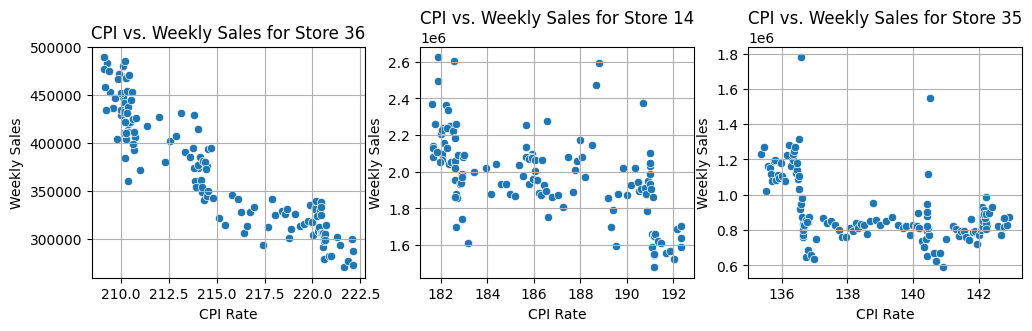

In [32]:
plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.scatterplot(data=df[df['Store']==36], x='CPI', y='Weekly_Sales')
plt.title('CPI vs. Weekly Sales for Store 36')
plt.xlabel('CPI Rate')
plt.ylabel('Weekly Sales')
plt.grid(True)

plt.subplot(1,3,2)
df_store14 = df[df['Store'] == 14].sort_values(by='CPI')
sns.scatterplot(data=df[df['Store']==14], x='CPI', y='Weekly_Sales')
plt.title('CPI vs. Weekly Sales for Store 14')
plt.xlabel('CPI Rate')
plt.ylabel('Weekly Sales')
plt.grid(True)

plt.subplot(1,3,3)
sns.scatterplot(data=df[df['Store']==35], x='CPI', y='Weekly_Sales')
plt.title('CPI vs. Weekly Sales for Store 35')
plt.xlabel('CPI Rate')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()


1e. Top performing stores according to the historical data.


In [33]:
new_df = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
new_df.head()

,Weekly_Sales
Store,
20,2.056650e+06
4,2.036610e+06
14,1.983411e+06
13,1.958935e+06
2,1.892591e+06


In [34]:
print(f'Top Performing Store: {new_df.index[0]}')

Top Performing Store: 20


1f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.

In [35]:
new_df.tail()

,Weekly_Sales
Store,
3,400064.846391
36,373953.448647
5,314892.276917
44,303253.622782
33,259656.216316


In [36]:
new_df = new_df.to_frame()

In [37]:
difference = new_df['Weekly_Sales'].values[0] - new_df['Weekly_Sales'].values[-1]
print(f'Difference Between Highest and Lowest Performing Stores: {difference:.2f}')

Difference Between Highest and Lowest Performing Stores: 1796994.18


**2. Use predictive modeling techniques to forecast the sales for each store for the next 12
weeks.**

In [38]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106


Enter the Store: 24


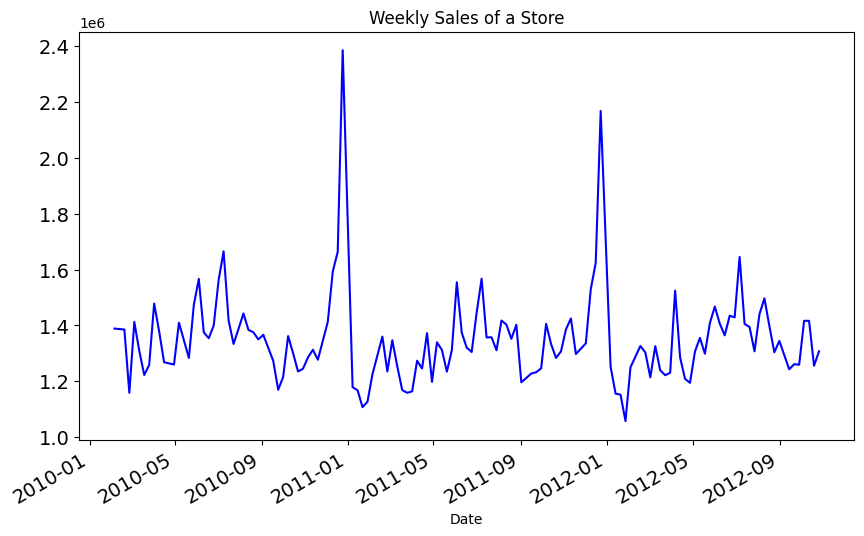

In [39]:
n = int(input('Enter the Store: '))
sales = df[df['Store']==n]
sales = sales[['Date' ,'Weekly_Sales']]
sales.set_index('Date', inplace=True)
sales.Weekly_Sales.plot(figsize=(10,6), title= 'Weekly Sales of a Store', fontsize=14, color = 'blue')
plt.show()

In [40]:
sales


,Weekly_Sales
Date,
2010-02-05,1388725.63
2010-02-19,1385362.49
2010-02-26,1158722.74
2010-03-05,1412387.37
2010-03-12,1309340.16
...,...
2012-09-28,1259278.36
2012-10-05,1416720.54
2012-10-12,1416301.17


<Figure size 640x480 with 0 Axes>

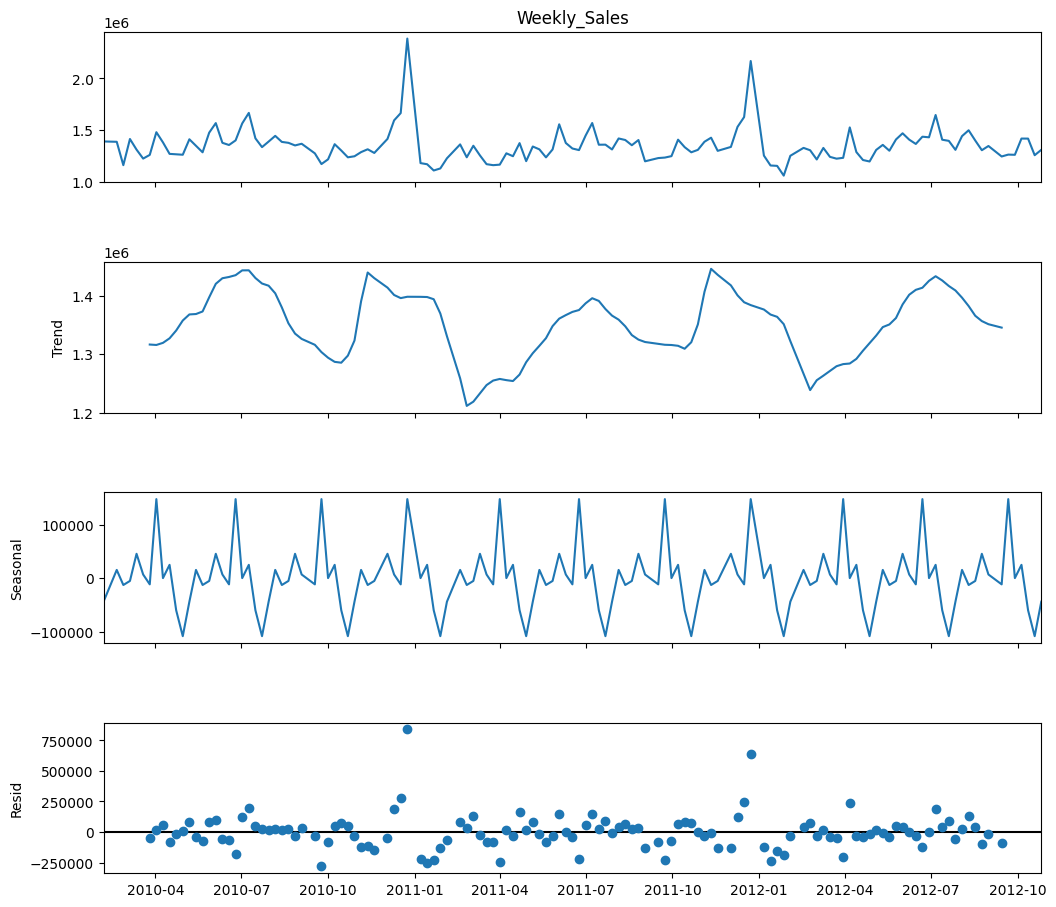

In [41]:
decomposition = seasonal_decompose(sales.Weekly_Sales, period=12)
fig = plt.figure()
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

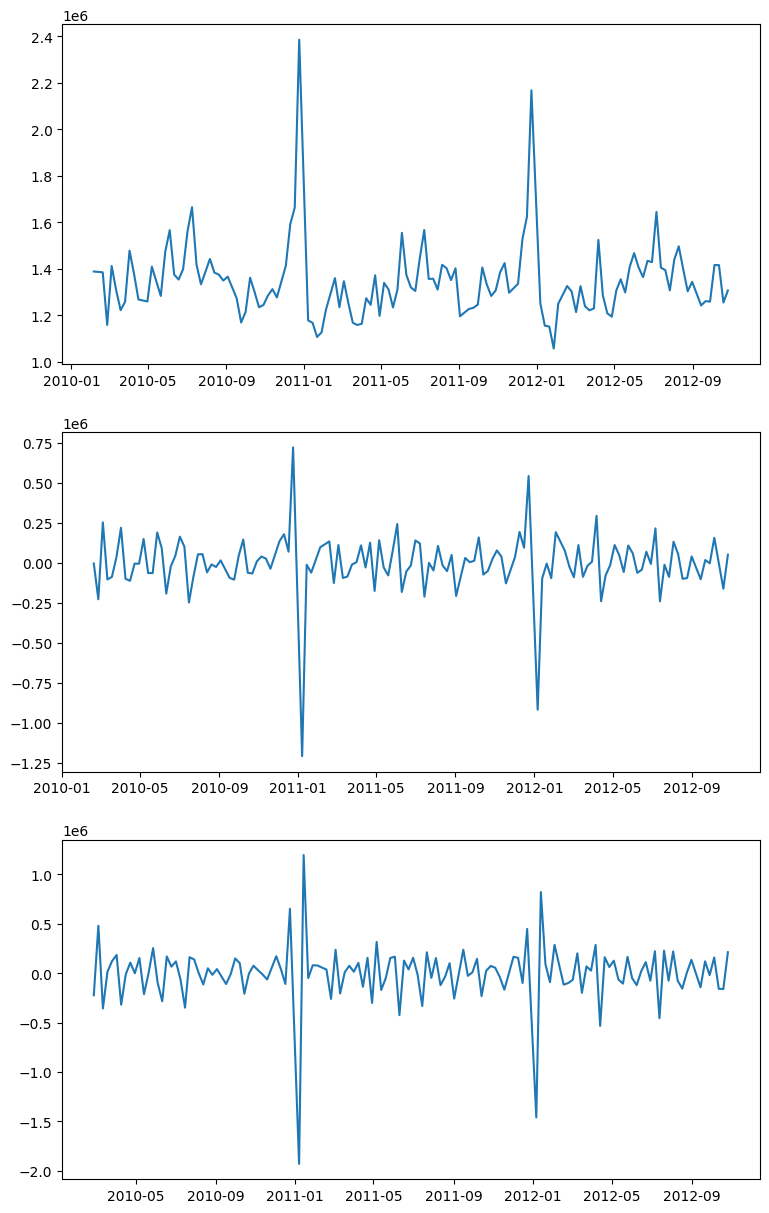

In [42]:
plt.figure(figsize = (9,15))

plt.subplot(3,1,1)
plt.plot(sales['Weekly_Sales'])

plt.subplot(3,1,2)
plt.plot(sales['Weekly_Sales'].diff())

plt.subplot(3,1,3)
plt.plot(sales['Weekly_Sales'].diff().diff())

plt.show()

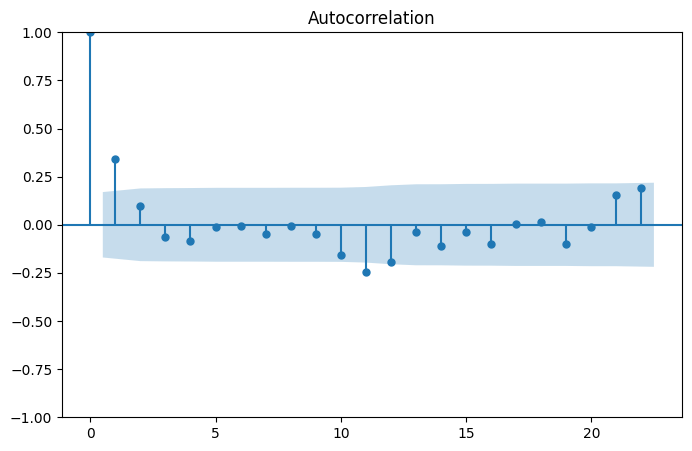

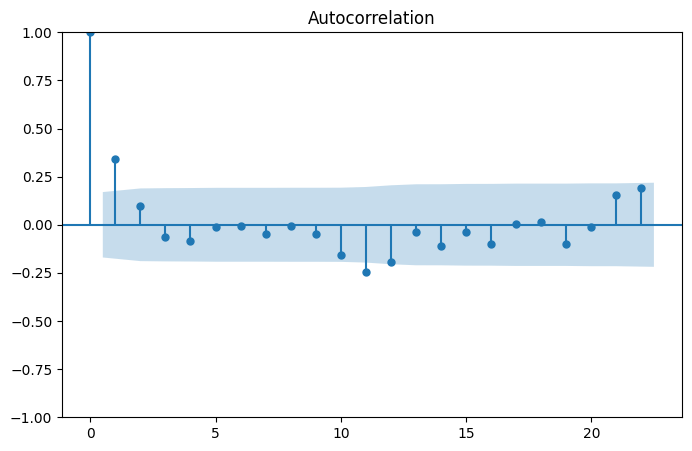

In [43]:
fig , ax = plt.subplots(figsize = (8,5))
plot_acf(sales['Weekly_Sales'] ,ax=ax )

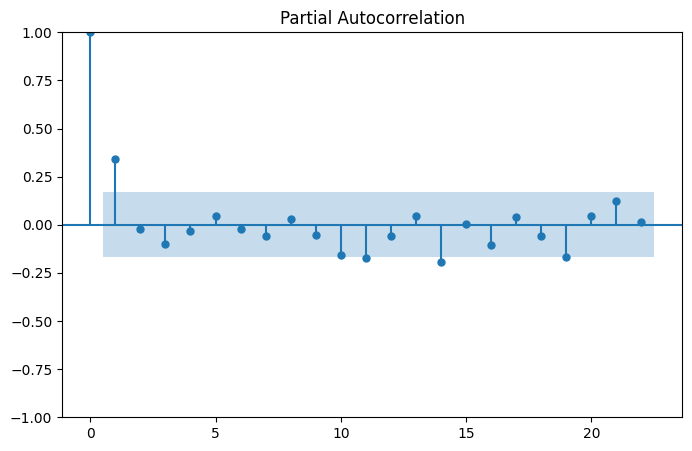

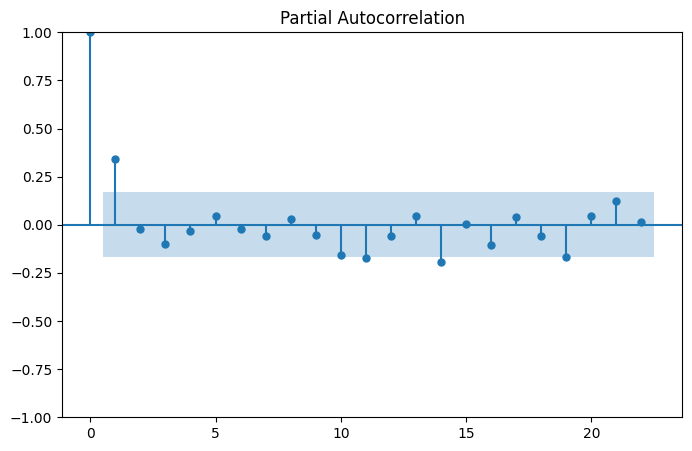

In [44]:
fig , ax = plt.subplots(figsize = (8,5))
plot_pacf(sales['Weekly_Sales'] ,ax=ax )

In [45]:
pip install pmdarima

In [46]:
from pmdarima import auto_arima

In [47]:
model = auto_arima(sales['Weekly_Sales'] ,
                   start_p=0 , start_q = 0 ,
                   start_P= 1 , start_Q = 1 ,
                   end_p = 5 , end_q = 5 ,
                   seasonal=True , m = 52 ,
                   error_action='ignore' ,
                   suppress_warnings=True)

In [48]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  133
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 52)   Log Likelihood               -1776.019
Date:                              Tue, 31 Mar 2026   AIC                           3560.037
Time:                                      12:51:19   BIC                           3571.599
Sample:                                           0   HQIC                          3564.735
                                              - 133                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   8.855e+05   6.98e+04     12.685      0.000    7.49e+05    1.02e+06
ar.L1          0.3425      0.043      7.979      0.000       0.258       0.427
ma.S.L52      -0.1839      0.132     -1.390      0.165      -0.443       0.075
sigma2      2.378e+10      0.401   5.93e+10      0.000    2.38e+10    2.38e+10
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               986.33
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):               0.84   Skew:                             2.20
Prob(H) (two-sided):                  0.55   Kurtosis:                        15.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.76e+26. Standard errors may be unstable.
"""

In [49]:
#model training
model_sarimax = SARIMAX(
    sales['Weekly_Sales'],
    order = (4,2,2),
    seasonal_order = (1,1,0,52)
)
result_sarimax = model_sarimax.fit()
result_sarimax.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                        Weekly_Sales   No. Observations:                  133
Model:             SARIMAX(4, 2, 2)x(1, 1, [], 52)   Log Likelihood               -1079.303
Date:                             Tue, 31 Mar 2026   AIC                           2174.607
Time:                                     12:51:49   BIC                           2193.562
Sample:                                          0   HQIC                          2182.201
                                             - 133                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0958      1.018     -0.094      0.925      -2.090       1.898
ar.L2         -0.0922      0.404     -0.228      0.819      -0.883       0.699
ar.L3         -0.0874      0.214     -0.408      0.684      -0.508       0.333
ar.L4         -0.3227      0.194     -1.661      0.097      -0.703       0.058
ma.L1         -1.1821      1.035     -1.143      0.253      -3.210       0.846
ma.L2          0.1978      1.041      0.190      0.849      -1.843       2.238
ar.S.L52      -0.5703      0.101     -5.647      0.000      -0.768      -0.372
sigma2      7.239e+10   6.91e-13   1.05e+23      0.000    7.24e+10    7.24e+10
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                56.10
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.42   Skew:                            -0.76
Prob(H) (two-sided):                  0.38   Kurtosis:                         6.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.69e+39. Standard errors may be unstable.
"""

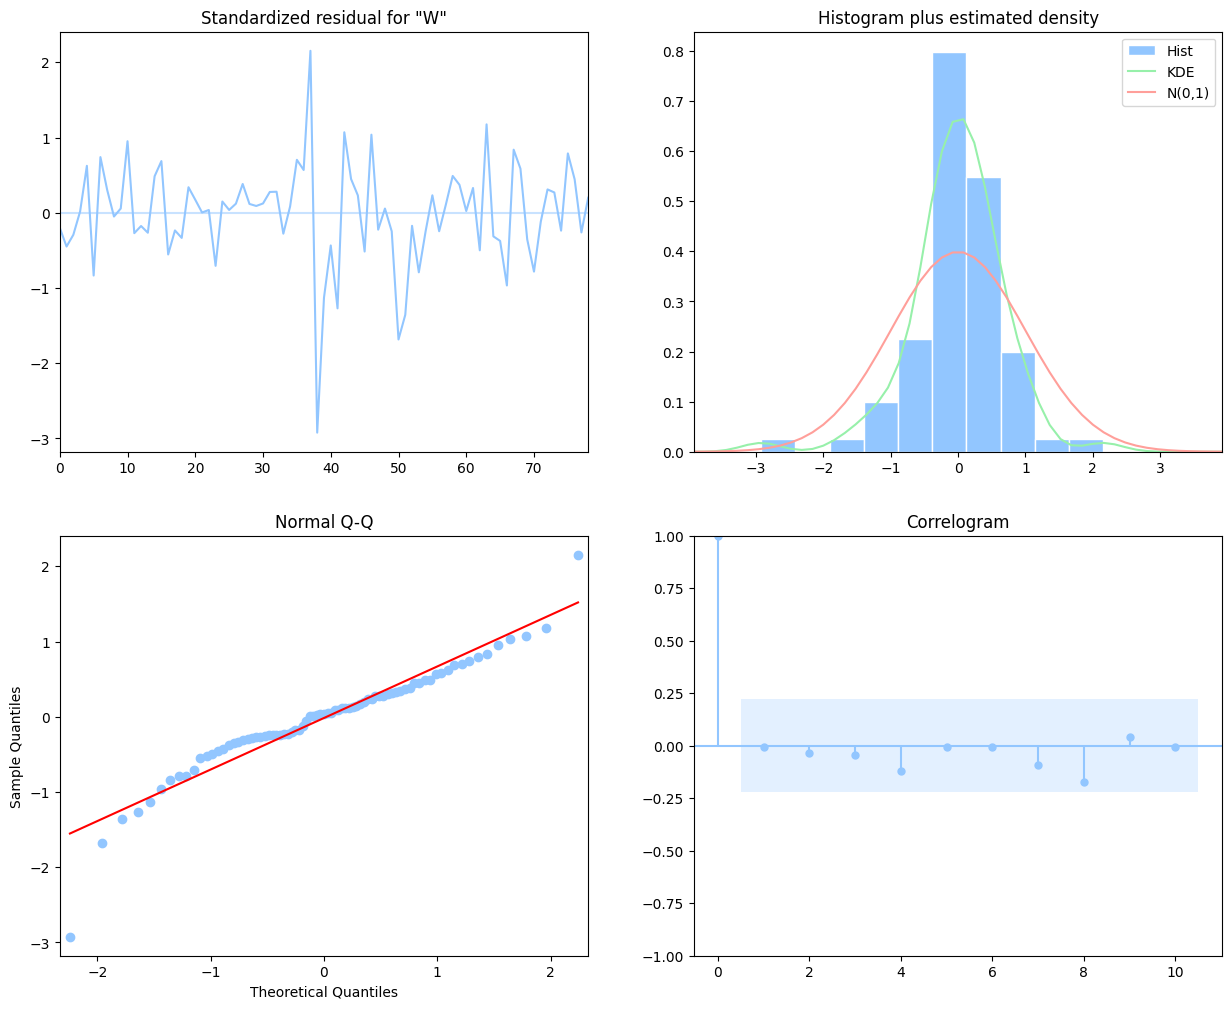

In [50]:
plt.style.use('seaborn-v0_8-pastel')
result_sarimax.plot_diagnostics(figsize=(15, 12))
plt.show()

In [51]:
n = 4
pred = result_sarimax.predict(len(sales['Weekly_Sales']) , len(sales['Weekly_Sales'])+n-1)
pred.to_frame()

start_date = '2012-10-26'

business_days = pd.date_range(start=start_date, periods=n, freq='7D')

df = pd.DataFrame({'Date': business_days, 'Value': pred})
df.set_index('Date' , drop = True , inplace = True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


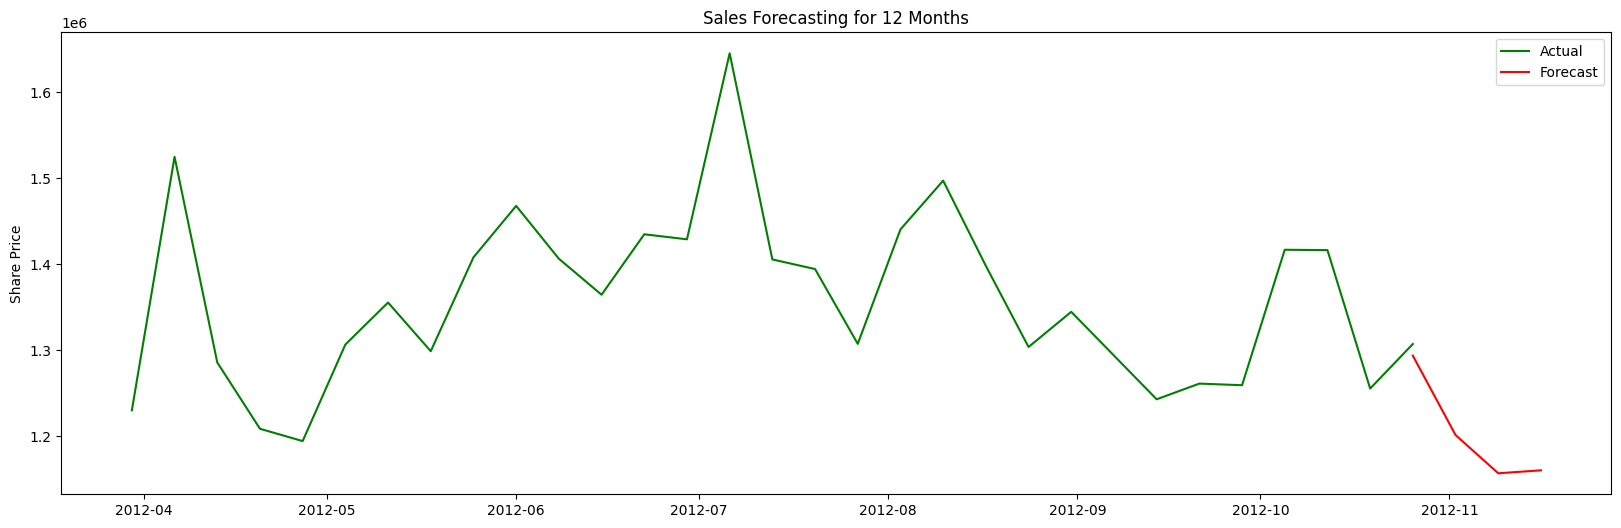

In [52]:
plt.figure(figsize = (20,6))
plt.plot(sales['Weekly_Sales'].iloc[-30:] , label = 'Actual', color = 'green')
plt.plot(df , label = 'Forecast' , color = 'red')
plt.ylabel("Share Price")
plt.title("Sales Forecasting for 12 Months")
plt.legend()
plt.show()

In [53]:
sales_forecasted = df.Value
sales_truth = sales[-n:]

mse = ((sales_forecasted.values- sales_truth['Weekly_Sales']) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 23153102291.48


In [54]:
rmse = np.sqrt(((sales_forecasted.values- sales_truth['Weekly_Sales']) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 152161.43


In [55]:
Residual= sales_forecasted.values- sales_truth['Weekly_Sales']
print("Residual for Store",np.abs(Residual).sum())

Residual for Store 583365.5780846628


In [56]:
pred = result_sarimax.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()

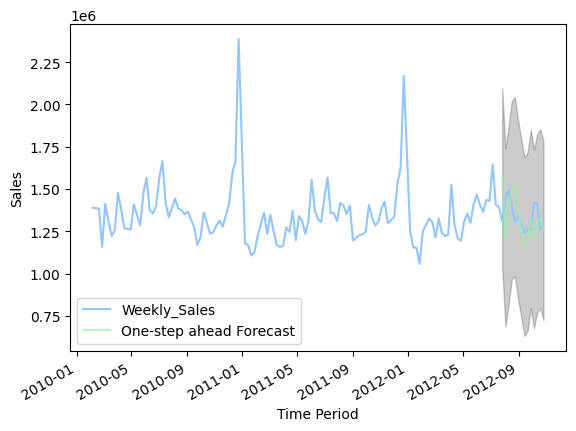

In [57]:
ax = sales['2010':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')
plt.legend()

plt.show()

In [58]:
pred_dynamic = result_sarimax.get_prediction(start=pd.to_datetime('2012-7-27'), dynamic=False, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()

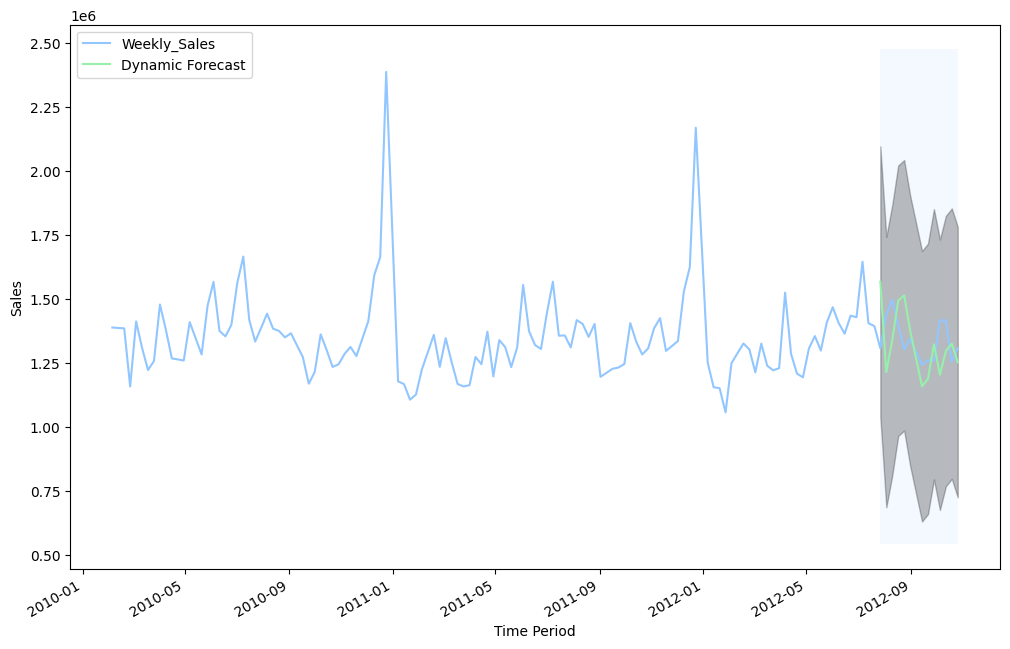

In [59]:
ax = sales['2010':].plot(label='observed', figsize=(12, 8))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)

ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('2012-7-26'), sales.index[-1],
                 alpha=.1, zorder=-1)

ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()

In [60]:
y_forecasted = pred.predicted_mean
y_truth = sales['Weekly_Sales']['2012-7-27':]

mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 21677688213.78


In [61]:
y_forecasted = pred_dynamic.predicted_mean
print(y_forecasted)

Date
2012-07-27    1.567610e+06
2012-08-03    1.214583e+06
2012-08-10    1.339209e+06
2012-08-17    1.493304e+06
2012-08-24    1.514388e+06
2012-08-31    1.376852e+06
2012-09-14    1.159381e+06
2012-09-21    1.188520e+06
2012-09-28    1.323252e+06
2012-10-05    1.204311e+06
2012-10-12    1.296496e+06
2012-10-19    1.325738e+06
2012-10-26    1.253326e+06
Name: predicted_mean, dtype: float64


In [62]:
y_truth = sales['2012-7-27':]

print(y_truth)

            Weekly_Sales
Date                    
2012-07-27    1307339.14
2012-08-03    1440374.13
2012-08-10    1497054.81
2012-08-17    1397970.54
2012-08-24    1303726.54
2012-08-31    1344558.92
2012-09-14    1242909.53
2012-09-21    1261158.47
2012-09-28    1259278.36
2012-10-05    1416720.54
2012-10-12    1416301.17
2012-10-19    1255414.84
2012-10-26    1307182.29


In [63]:
Residual= y_forecasted - y_truth['Weekly_Sales']
print("Residual for Store",np.abs(Residual).sum())

Residual for Store 1658729.3297329885


In [64]:
rmse = np.sqrt(((y_forecasted - y_truth['Weekly_Sales']) ** 2).mean())
print('The Root Mean Squared Error of our forecasts is {}'.format(round(rmse, 2)))

The Root Mean Squared Error of our forecasts is 147233.45


In [65]:
pred_uc = result_sarimax.get_forecast(steps=12)

print(pred_uc)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [66]:
pred_ci = pred_uc.conf_int()

In [67]:
pred_ci

,lower Weekly_Sales,upper Weekly_Sales
133,765972.034112,1.821270e+06
134,550191.411198,1.852543e+06
135,414953.048973,1.898885e+06
136,346615.797404,1.974076e+06
137,453617.083519,2.124679e+06
138,377673.851440,2.129904e+06
139,212044.350923,2.056959e+06
140,179278.946160,2.124115e+06
141,205933.225825,2.274497e+06
142,203010.126221,2.373607e+06


In [68]:
n = len(y_truth)-1
start_date = '2012-10-26'

business_days = pd.date_range(start=start_date, periods=n, freq='7D')

df = pd.DataFrame({'Date': business_days, 'Value': pred_uc.predicted_mean})
df.set_index('Date' , drop = True , inplace = True)
pred_ci = pd.DataFrame({'Date': business_days, 'Lower_Weekly_Sales': pred_ci['lower Weekly_Sales'] , 'Upper_Weekly_Sales': pred_ci['upper Weekly_Sales']})
pred_ci.set_index('Date' , drop = True , inplace = True)

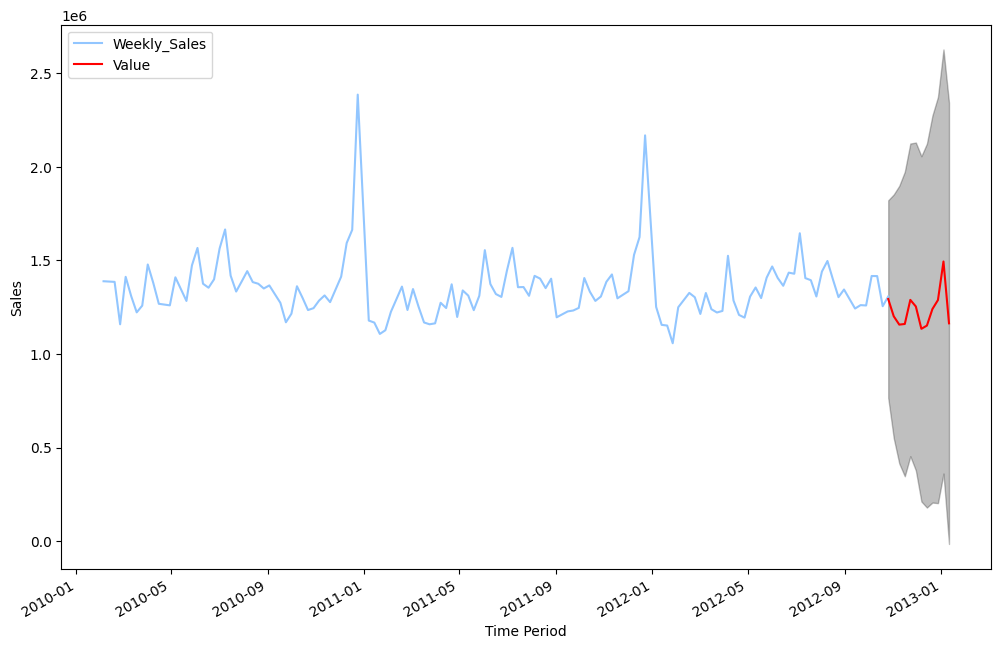

In [69]:
ax = sales.plot(label='observed', figsize=(12, 8))
df.plot(ax=ax, label='Forecast' , color = 'red')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Time Period')
ax.set_ylabel('Sales')

plt.legend()
plt.show()